In [2]:
import pandas as pd



data_path = "/home/thhaase/Documents/synosys_internship"

d = pd.read_parquet(f'{data_path}/llm_coding.parquet')

# Calculate Final Score

$\text{finalScore} = (\text{populistScore} - \text{elitistScore}) \cdot \text{intensityScore}$
- Max: $(3 - (-3)) \cdot 3 = 6 \cdot 3 = 18$
- Min: $(-3 - (3)) \cdot 3 = 6 \cdot 3 = -18$

If there is no divide or strong language (intensity = 0) there will be no populist rethoric

The normalized score is calculated through
$\text{finalScoreNormalized} = \frac{\text{finalScore} + 18}{36}$

In [3]:
d["final_score"] = (d["populist_score"] - d["elitist_score"]) * d["intensity_score"]
d["final_score_normalized"] = (d["final_score"] + 18) / 36

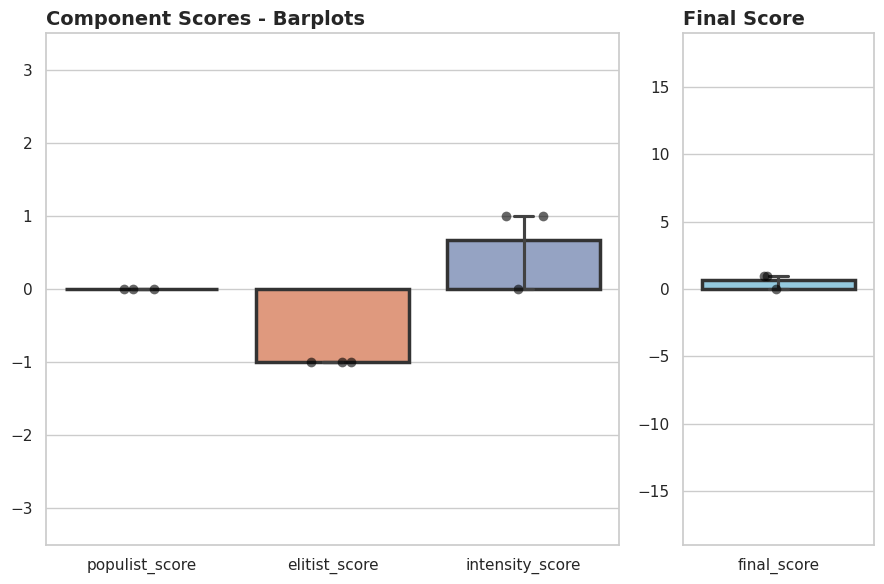

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set theme
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(9, 6), gridspec_kw={'width_ratios': [3, 1]})

# --- Left Panel: Component Scores ---
sns.barplot(
    data=d[["populist_score", "elitist_score", "intensity_score"]], 
    ax=axes[0], 
    palette=["#ef926e", "#ef926e", "#8da0cb"], 
    linewidth=2.5,
    edgecolor=".2",    # Adds a dark edge to the bars
    capsize=0.1        # Adds caps to the error bars (Confidence Interval)
)

sns.stripplot(
    data=d[["populist_score", "elitist_score", "intensity_score"]], 
    ax=axes[0], 
    color="#000000", 
    alpha=0.6, 
    jitter=0.15,
    size=7
)

# loc='left' aligns the title to the left edge of the plot area
axes[0].set_title("Component Scores - Barplots", loc='left', fontsize=14, fontweight='bold')
axes[0].set_ylim(-3.5, 3.5)

# --- Right Panel: Final Score ---
sns.barplot(
    data=d[["final_score"]], 
    ax=axes[1], 
    color="skyblue", 
    linewidth=2.5,
    edgecolor=".2",
    capsize=0.1
)

sns.stripplot(
    data=d[["final_score"]], 
    ax=axes[1], 
    color="#000000", 
    alpha=0.6, 
    jitter=0.15,
    size=7
)

# loc='left' aligns the title to the left edge of the plot area
axes[1].set_title("Final Score", loc='left', fontsize=14, fontweight='bold')
axes[1].set_ylim(-19, 19)

plt.tight_layout()
plt.show()